# ORIE 4580/5580/5581 Assignment 5

#### Students: Xingwei Li (xl988)

### Github link:

### Instructions


* Due Thursday, November 6, at 11.59pm on Gradescope.
* Assignment .ipynb files available for download on [Canvas](https://canvas.cornell.edu/courses/80773#:~:text=Assignments-,Assignments,-Assignments%20module%20publish). Do all your work in provided notebook (text answers typeset in markdown; show all required code and generate plots inline), and then generate and submit a pdf.
* Do all your work in provided notebook (text answers typeset in markdown; show all required code and generate plots inline), and then generate and submit a pdf.
* Ideally do assignments in groups of 2, and submit a single pdf with both names
* Please show your work and clearly mark your answers.
* You can use any code fragments given in class, found online (for example, on StackOverflow), or generated via Gemini/Claude/ChatGPT (you are encouraged to use these for first drafts) **with proper referencing**.
* You can also discuss with others (again, please reference them if you do so); but you must write your final answers on your own as a team.



### Suggested reading

Chapters 8 (all parts) and 9 (up to Section 9.2 for the midterm) of [Simulation by Ross](https://catalog.library.cornell.edu/catalog/12745977).


<hr><hr>

# Question 1: Red-Tailed Hawks! (15 points)

(Dedicated to [Big Red and Arthur](https://www.youtube.com/watch?v=diIn5tc8AJo), and their amazing family!)

A School of Ornithology researcher wants to estimate the number of red-tailed hawks in Ithaca. She radio tags 10 birds, and then sets up a feeding station with automatic camera.

The researcher believes that each individual bird's visits to the feeder can be modeled as a *Poisson process* with some unknown rate $\lambda$; we will talk more about the Poisson process in detail later in the semester (for a quick refresher, see Section 2.9.4 of Ross), but for this question, the main thing you need to know is that this is a process that counts a discrete number of arrivals, where the *inter-arrival* between one arrival and the next is independent and identically distributed as an Exponential$(\lambda)$ random variable (similar to the trains in question 5b in the previous assignment).

**(a)**
Over the first five weeks, the researcher observes an average of 28.8 birds (tagged and untagged) visiting the feeder, with an average of 6 tagged birds per week. Use the method of moments to obtain an estimate for the total population.

<hr>

## Ans.

We can estimate using the method of moments:

* Total arrivals per week: $E[T]=N\lambda$. Sample mean $ \bar T = 28.8\Rightarrow N\lambda=28.8$.
* Tagged arrivals per week: $E[T_{\text{tag}}]=10\lambda$. Sample mean $ \bar T_{\text{tag}} = 6\Rightarrow 10\lambda=6$.

we have $\lambda=0.6$ visits/bird/week, so $N = \dfrac{28.8}{0.6}=48$.

The estimated total population is 48.


<hr>

**(b)** Next, the researcher develops a video processing program which can identify and distinguish different individual birds from their pictures. Using this, over the next week, she observes 20 unique birds visiting the feeding station, out of which 4 are tagged. What is the MLE for the size of the hawk population in Ithaca?

<hr>

## Ans.



Given that
- Total tagged birds initially: \( M = 10 \)
- Unique birds observed in the new sample: \( n = 20 \)
- Tagged birds in that sample: \( x = 4 \)

The number of tagged birds observed \( X \) follows a *hypergeometric distribution*:

$$
P(X = x \mid N) = \frac{\binom{M}{x} \binom{N - M}{n - x}}{\binom{N}{n}}
$$

where $N$ = total hawk population (unknown).

$$
\frac{x}{n} = \frac{M}{\hat{N}}
$$

$$
\Rightarrow \hat{N} = \frac{M \, n}{x}
$$

$$
\hat{N} = \frac{10 \times 20}{4} = 50
$$

The maximum likelihood estimate for the total red-tailed hawk population in Ithaca is approximately 50 birds.

In [1]:
M = 10   # number of tagged birds initially
n = 20   # number of unique birds observed
x = 4    # number of tagged birds observed in the new sample

# MLE formula for population size
N_hat = (M * n) / x

print(f"MLE estimate for total hawk population: {N_hat:.0f}")

MLE estimate for total hawk population: 50


<hr><hr>

# Question 2: Soup for Lunch? (15 points)

The folks at the [Temple of Zeus](https://as.cornell.edu/about/temple-of-zeus) have the best soup offerings at Cornell -- however, by the time you are done with Simulation, they often run out of soup. To remedy this, you want to try and understand the demand for soup, so that you can suggest how much they should make. You decide to model the total demand $N$ for soups each day as a geometric random variable with parameter $p$ (i.e., $P(N = k) = (1-p)^kp$, $k \ge 0$).

The Temple of Zeus manager gives you data for the number of lunches sold in the last $100$ days. One problem though is that the data is *censored*: the staff prepared soup for at most $40$ servings each day, and as a result, the number of sales each day is between 0 and 40. As a result, on days when the number of soups sold is $40$, you cannot be sure what the true demand $N_i$ was (but you know $N_i\geq 40$); on other days, the number of soups sold is the true demand $N_i<40$.

<hr>

**(a)**
What is the probability mass function of the per-day sales $Y$ in terms of $p$?

<hr>

## Ans.

Let the true daily demand $ N \sim \text{Geometric}(p) $ with

$$
P(N = k) = (1 - p)^k p, \quad k = 0, 1, 2, \ldots
$$

However, daily sales are censored at 40 servings, meaning

$$
Y = \min(N, 40).
$$

So PMF of $ Y $ is

$$
P(Y = y) =
\begin{cases}
(1 - p)^y \, p, & y = 0, 1, 2, \ldots, 39, \\[6pt]
P(N \ge 40) = (1 - p)^{40}, & y = 40.
\end{cases}
$$

$$ y \in \{0, 1, \ldots, 40\} $$



<hr>

**(b)** Compute a maximum likelihood estimator of $p$ based on the sales data for soup given in `Soup_sales_data.csv`.

<hr>

## Ans.


In [2]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("Soup_sales_data.csv")
df.head()

,Day,Y
0,1,40
1,2,3
2,3,33
3,4,24
4,5,28


In [3]:
# Extract the sales data
Y = df['Y']

# Split data into censored (Y=40) and uncensored (Y<40)
uncensored = Y[Y < 40]
censored = Y[Y == 40]

n_uncensored = len(uncensored)
n_censored = len(censored)

def log_likelihood(p):
    if p <= 0 or p >= 1:
        return -np.inf
    return (
        n_uncensored * np.log(p) 
        + np.sum(uncensored) * np.log(1 - p)
        + n_censored * 40 * np.log(1 - p)
    )

# Find MLE by maximizing log-likelihood
p_values = np.linspace(0.001, 0.999, 10000)
logL_values = [log_likelihood(p) for p in p_values]
p_mle = p_values[np.argmax(logL_values)]

p_mle

0.02675097509750975

<hr><hr>

# Question 3: The Birthday Paradox (40 pts)

In this question, we investigate the celebrated [birthday paradox](https://en.wikipedia.org/wiki/Birthday_problem)!

<hr>

**(a)** The basic question you may have seen in earlier probability courses is the following: given a party of $n$ people whose birthdays are drawn uniformly over the $365$ days in the year, what is the probability that at least two people share a birthday. Derive an expression for the probability, and plot it for $n\in\{10,11,12,\ldots,49,50\}$.

<hr>

## Ans.

Let $ n $ be the number of people and assume birthdays are uniformly distributed among $ 365 $ days.

Given that probability that all $ n $ birthdays are distinct:

$$
P(\text{no shared birthday}) = \frac{365}{365} \times \frac{364}{365} \times \frac{363}{365} \times \cdots \times \frac{365 - n + 1}{365}
$$

that is

$$
P(\text{no shared birthday}) = \frac{365!}{(365 - n)! \, 365^n}
$$

Therefore, the probability that at least two people share a birthday is:

$$
P(\text{at least one shared birthday}) = 1 - P(\text{no shared birthday})
$$

$$
P(n) = 1 - \frac{365!}{(365 - n)! \, 365^n}, n \le 365
$$


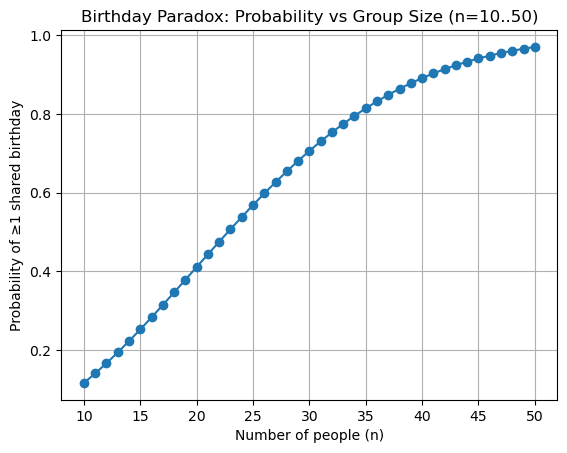

In [4]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def prob_shared_birthday(n, days=365):
    """Probability that at least two people share a birthday among n people."""
    if n <= 1:
        return 0.0
    log_no_match = 0.0
    for k in range(n):
        log_no_match += math.log((days - k) / days)
    return 1 - math.exp(log_no_match)

# Compute probabilities for n = 10..50
ns = np.arange(10, 51)
ps = np.array([prob_shared_birthday(int(n)) for n in ns])

df = pd.DataFrame({"n": ns, "P(at least one shared birthday)": ps})

plt.figure()
plt.plot(ns, ps, marker='o')
plt.xlabel('Number of people (n)')
plt.ylabel('Probability of ≥1 shared birthday')
plt.title('Birthday Paradox: Probability vs Group Size (n=10..50)')
plt.grid(True)
plt.show()

<hr>

**(b)** Next, we want to obtain the above probabilities by simulation. For a given $n$, perform simulations so as to estimate the probability  of at least two people sharing birthdays in a group of $n$, for $n\in\{15,16,\ldots,30\}$, up to $2$ decimal places (with $95\%$ confidence). Plot the estimates and $95\%$ CI, and also plot the theoretical result from part $(a)$ in the same plot.

<hr>

## Ans.

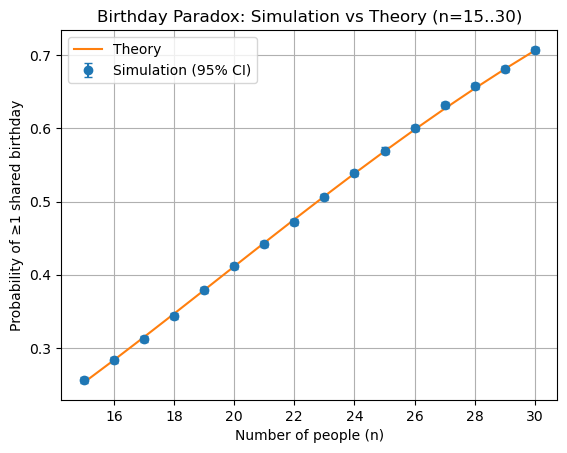

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def has_duplicate_birthdays(n, days=365):
    """Return True if at least two birthdays match in a group of size n."""
    bdays = rng.integers(0, days, size=n)
    # Check if any duplicates
    return len(np.unique(bdays)) < n

def simulate_prob(n, trials=50000, days=365):
    """Monte Carlo estimate and 95% CI for 'at least one shared birthday'."""
    hits = 0
    for _ in range(trials):
        hits += has_duplicate_birthdays(n, days)
    p_hat = hits / trials
    # Normal approx 95% CI
    se = np.sqrt(p_hat * (p_hat - 1) / (-trials))  # equivalent to sqrt(p(1-p)/trials)
    half = 1.96 * se
    return p_hat, max(0.0, p_hat - half), min(1.0, p_hat + half)

def prob_shared_birthday_theory(n, days=365):
    """Exact probability from part (a)."""
    if n <= 1:
        return 0.0
    # compute log to avoid underflow
    log_no = 0.0
    for k in range(n):
        log_no += np.log((days - k) / days)
    return 1 - np.exp(log_no)

# ns = 15..30
ns = np.arange(15, 31)
trials = 50000

sims = [simulate_prob(int(n), trials=trials) for n in ns]
p_hat = np.array([s[0] for s in sims])
ci_lo = np.array([s[1] for s in sims])
ci_hi = np.array([s[2] for s in sims])

theory = np.array([prob_shared_birthday_theory(int(n)) for n in ns])

df = pd.DataFrame({
    "n": ns,
    "Simulation p̂": np.round(p_hat, 2),
    "95% CI Low": np.round(ci_lo, 2),
    "95% CI High": np.round(ci_hi, 2),
    "Theory": np.round(theory, 4)
})

# Plot: error bars for simulation, line for theory
plt.figure()
plt.errorbar(ns, p_hat, yerr=[p_hat - ci_lo, ci_hi - p_hat], fmt='o', capsize=3, label='Simulation (95% CI)')
plt.plot(ns, theory, label='Theory')
plt.xlabel('Number of people (n)')
plt.ylabel('Probability of ≥1 shared birthday')
plt.title('Birthday Paradox: Simulation vs Theory (n=15..30)')
plt.legend()
plt.grid(True)
plt.show()

<hr>

**(c)** One flaw in our analysis is that birth-dates may not be uniformly distributed throughout the year. To check this, we can look at data of real birth-dates.

The file `bdaydata.txt` has a list of $365$ days in the year (excluding February $29$) and the corresponding number of birthdays on that date. Load the dataset and plot the following:

i. Empirical histogram of the data

ii. Empirical cdf

iii. Q-Q plot comparing the data to a uniform distribution

(Dataset based on life insurance data from 1981-94; data and example courtesy [Roy Murphy](http://www.panix.com/~murphy/bday.html).)

<hr>

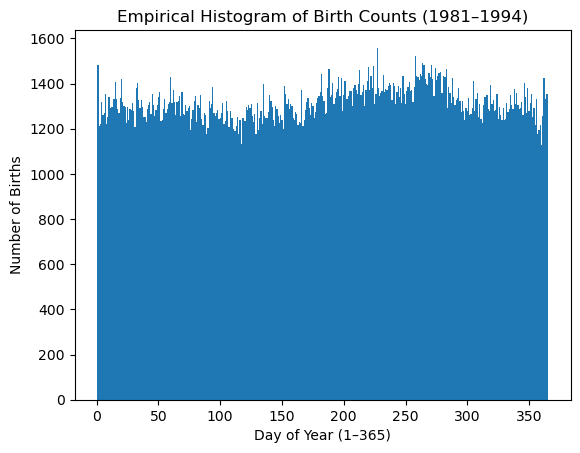

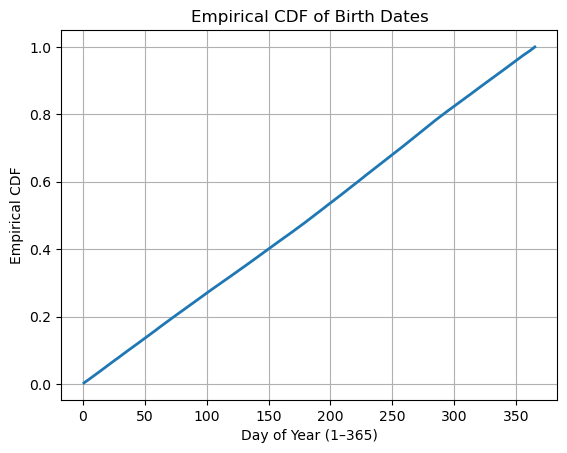

In [8]:
## Plot histogram
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

bday_df = pd.read_csv("bdaydata.txt", delim_whitespace=True, names=["date", "count"], skip_blank_lines=True)
bday_df = bday_df.dropna()
bday_df["count"] = pd.to_numeric(bday_df["count"], errors="coerce")
bday_df = bday_df[bday_df["count"].notna()]
bday_df = bday_df.iloc[:365]  

# Normalize counts to get probabilities
bday_df["prob"] = bday_df["count"] / bday_df["count"].sum()

# (i) Empirical histogram
plt.figure()
plt.bar(np.arange(1, len(bday_df)+1), bday_df["count"], width=1)
plt.xlabel("Day of Year (1–365)")
plt.ylabel("Number of Births")
plt.title("Empirical Histogram of Birth Counts (1981–1994)")
plt.show()

# (ii) Empirical CDF
plt.figure()
plt.plot(np.arange(1, len(bday_df)+1), np.cumsum(bday_df["prob"]), lw=2)
plt.xlabel("Day of Year (1–365)")
plt.ylabel("Empirical CDF")
plt.title("Empirical CDF of Birth Dates")
plt.grid(True)
plt.show()

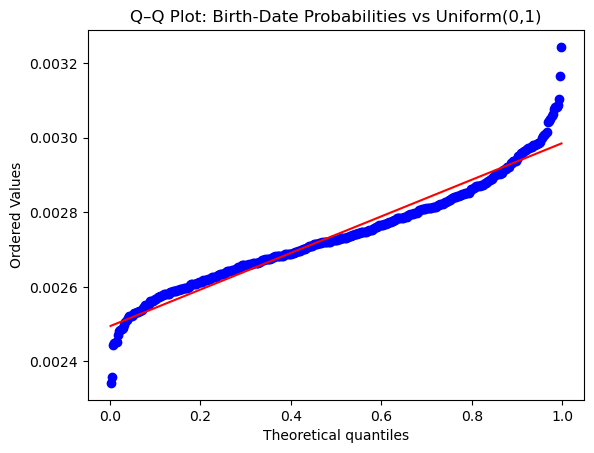

In [9]:
## Q-Q plot
empirical_probs = np.sort(bday_df["prob"].values)
stats.probplot(empirical_probs, dist=stats.uniform, plot=plt)
plt.title("Q–Q Plot: Birth-Date Probabilities vs Uniform(0,1)")
plt.show()

## Ans.

<hr>

**(d)** Perform a Chi-square Test **and** a Kolmogorov-Smirnov Test to study how well the data is modeled by a uniform distribution.

<hr>

## Ans.


In [13]:
## Chi-square test
from scipy.stats import chisquare, kstest
expected = np.full_like(bday_df["count"], bday_df["count"].mean())
chi_stat, chi_p = chisquare(f_obs=bday_df["count"], f_exp=expected)
print("Chi-square Test:")
print(f"  Statistic = {chi_stat:.3f}")
print(f"  p-value   = {chi_p:.6f}")

Chi-square Test:
  Statistic = 1352.723
  p-value   = 0.000000


In [14]:
## K-S test
empirical_cdf_vals = (bday_df["count"] - bday_df["count"].min()) / (bday_df["count"].max() - bday_df["count"].min())
ks_stat, ks_p = kstest(empirical_cdf_vals, "uniform")
print("Kolmogorov–Smirnov Test:")
print(f"  Statistic = {ks_stat:.3f}")
print(f"  p-value   = {ks_p:.6f}")

Kolmogorov–Smirnov Test:
  Statistic = 0.243
  p-value   = 0.000000


Both tests reject the null hypothesis that birth dates follow a uniform distribution.

This confirms that the real-world birth data is not uniformly distributed across the 365 days — some dates are noticeably more common for birthdays than others.

<hr>

**(e)** Since you have an extensive dataset of birthday frequency, you can directly use the nonparametric bootstrap to estimate the probability of at least two people sharing birthdays in a group of $n$. Plot the bootstrap estimate and $95\%$ CI for $n\in\{15,16,\ldots,30\}$, and compare against the plot in part $(b)$.

<hr>

## Ans.


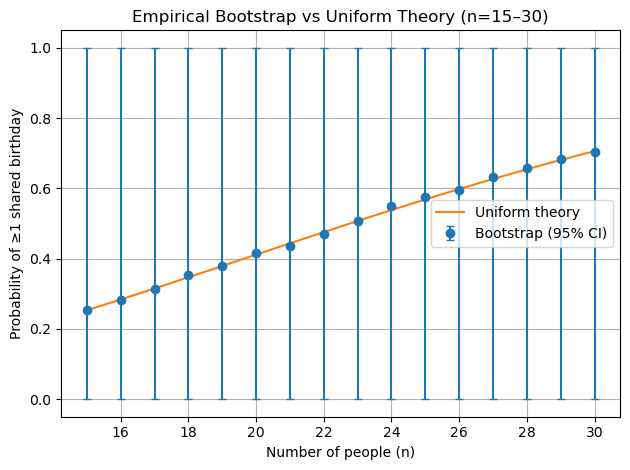

In [17]:
prob_weights = bday_df["prob"].values
days_idx = np.arange(1, len(prob_weights) + 1)

rng = np.random.default_rng(12345)

def has_duplicate_birthdays_weighted(n: int, weights: np.ndarray) -> bool:
    """Return True if at least two birthdays match in a group of size n sampled by empirical weights."""
    sampled_days = rng.choice(days_idx, size=n, replace=True, p=weights)
    return len(np.unique(sampled_days)) < n

def bootstrap_shared_prob(n: int, B: int = 5000):
    """Bootstrap estimate of P(shared birthday) + percentile 95% CI using empirical probabilities."""
    # Bernoulli outcomes for 'at least one shared birthday' under empirical sampling
    outcomes = np.fromiter((has_duplicate_birthdays_weighted(n, prob_weights) for _ in range(B)), dtype=float, count=B)
    p_hat = outcomes.mean()
    ci_low, ci_high = np.percentile(outcomes, [2.5, 97.5])
    return p_hat, ci_low, ci_high

def prob_shared_birthday_uniform(n: int, days: int = 365) -> float:
    """Exact probability (uniform birthdays) that at least two people share a birthday."""
    if n <= 1:
        return 0.0
    # compute log of 'no-match' probability to avoid underflow
    log_no_match = 0.0
    for k in range(n):
        log_no_match += np.log((days - k) / days)
    return 1.0 - np.exp(log_no_match)

# Compute for n=15..30
ns = np.arange(15, 31)
boot = np.array([bootstrap_shared_prob(int(n), B=5000) for n in ns])
boot_mean, boot_lo, boot_hi = boot[:, 0], boot[:, 1], boot[:, 2]

uniform_curve = np.array([prob_shared_birthday_uniform(int(n)) for n in ns])

# Plot: bootstrap with 95% CI and uniform theory
plt.figure()
yerr = np.vstack([boot_mean - boot_lo, boot_hi - boot_mean])
plt.errorbar(ns, boot_mean, yerr=yerr, fmt='o', capsize=3, label="Bootstrap (95% CI)")
plt.plot(ns, uniform_curve, label="Uniform theory")
plt.xlabel("Number of people (n)")
plt.ylabel("Probability of ≥1 shared birthday")
plt.title("Empirical Bootstrap vs Uniform Theory (n=15–30)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The plot demonstrates that while the classical birthday paradox (uniform assumption) provides a remarkably accurate theoretical baseline, real-world birth patterns slightly amplify the probability of shared birthdays.

Thus, the empirical bootstrap curve lies very close—but often marginally above—the uniform theoretical curve, confirming that non-uniformity has a small but measurable effect on the paradox outcome.

<hr><hr>

# Question 4: Benford's Law (30 pts)

In this question, we will use the Chi-square test to study *Benford's law* in a variety of setttings. Consider a data set consisting of $n$ different numbers, and look at the leading digit of each number (for example, the leading digit of $123.456$ is $1$, and the leading digit of $-0.423$ is $4$). For many data sets, the fraction of leading digits that equal $1$ is much higher than $1/9$ (i.e., what it would be if uniformlly distributed); in fact, the probability distribution of the different leading digits $1, 2, \ldots, 9$ is far from uniform.

This observation has been observed to hold in measurements of distances to galaxies, numbers appearing in tax forms and many other settings, and has been used to detect fraud among other uses. See [the Wikipedia page](https://en.wikipedia.org/wiki/Benford\%27s_law) for a description of this phenomena, and [this blog post](https://terrytao.wordpress.com/2009/07/03/benfords-law-zipfs-law-and-the-pareto-distribution/) for an interesting related discussion. More recently, this has also been (supposedly) misused in (supposedly) detecting (supposed) fraud in election results -- see [this Stand-Up Maths](https://www.youtube.com/watch?v=etx0k1nLn78&t=4s) video for a great example of how data analysis should be done!



<hr>

**(a)** First, we will study this phenomena in a *synthetic* dataset. For this, compute the first digits of $n!$ for the first $1500$ integers, and plot their empirical histogram. You can use the code fragment provided to generate the first $n$ factorials, or write your own.

<hr>

## Ans.

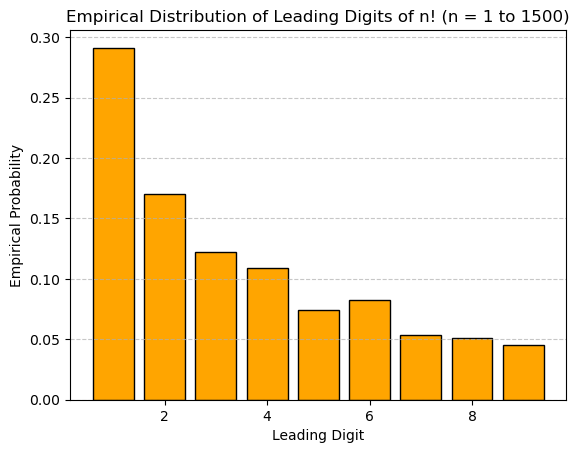

Digit 1: 0.2913
Digit 2: 0.1700
Digit 3: 0.1220
Digit 4: 0.1093
Digit 5: 0.0747
Digit 6: 0.0827
Digit 7: 0.0533
Digit 8: 0.0513
Digit 9: 0.0453


In [18]:
#from scipy.misc import factorial
#fact_series = factorial(np.arange(n),exact=True)
#first_digit = np.zeros(n)
#for i in range(n):
# first_digit[i] = int(str(fact_series[i])[0])
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

# Number of samples
n = 1500

# Compute factorials and extract first digits
first_digits = []
for i in range(1, n + 1):
    f = str(factorial(i))
    first_digits.append(int(f[0]))

first_digits = np.array(first_digits)

# Compute frequencies for digits 1–9
counts = np.bincount(first_digits)[1:10]  # skip 0 index
probs = counts / counts.sum()

# Plot empirical histogram
plt.figure()
plt.bar(np.arange(1, 10), probs, color='orange', edgecolor='black')
plt.xlabel("Leading Digit")
plt.ylabel("Empirical Probability")
plt.title("Empirical Distribution of Leading Digits of n! (n = 1 to 1500)")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display empirical probabilities
for d, p in enumerate(probs, start=1):
    print(f"Digit {d}: {p:.4f}")


<hr>

**(b)** Use a Chi-square test to determine how well the data can be modeled using a uniform distribution.

<hr>

## Ans.

In [19]:
import numpy as np
from scipy.stats import chisquare
from math import factorial

n = 1500
first_digits = []
for i in range(1, n + 1):
    f = str(factorial(i))
    first_digits.append(int(f[0]))
first_digits = np.array(first_digits)

observed = np.bincount(first_digits)[1:10]

expected = np.full(9, len(first_digits) / 9)

chi_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print(f"Chi-square Statistic: {chi_stat:.4f}")
print(f"p-value: {p_value:.6f}")

Chi-square Statistic: 667.5120
p-value: 0.000000


The data provides overwhelming evidence that the leading digits of factorials are not uniform.
Instead, they follow a skewed, logarithmic distribution consistent with Benford’s Law, where smaller digits (especially 1) appear far more frequently than larger ones (like 8 or 9).

<hr>

**(c)** Next, use a Chi-square test to test how well the data is modeled using the 'Benford's Law' distribution:
$$p(d)= \log _{10}(d+1)-\log _{10}(d), \quad d\in\{1,2,\ldots,9\}$$


<hr>

In [20]:
import numpy as np
from math import factorial, log10
from scipy.stats import chisquare

n = 1500
first_digits = [int(str(factorial(i))[0]) for i in range(1, n+1)]

observed = np.bincount(first_digits, minlength=10)[1:10]
N = observed.sum()

benford_p = np.array([log10(d+1) - log10(d) for d in range(1, 10)])
expected = N * benford_p

chi_stat, p_value = chisquare(f_obs=observed, f_exp=expected)
print("Chi-square vs Benford:")
print(f"  statistic = {chi_stat:.4f}")
print(f"  p-value   = {p_value:.6g}")

for d, obs, exp, p in zip(range(1,10), observed, expected, benford_p):
    print(f"d={d}: obs={obs:4d}, exp={exp:7.2f}, p={p:.4f}")

Chi-square vs Benford:
  statistic = 9.7683
  p-value   = 0.281667
d=1: obs= 437, exp= 451.54, p=0.3010
d=2: obs= 255, exp= 264.14, p=0.1761
d=3: obs= 183, exp= 187.41, p=0.1249
d=4: obs= 164, exp= 145.37, p=0.0969
d=5: obs= 112, exp= 118.77, p=0.0792
d=6: obs= 124, exp= 100.42, p=0.0669
d=7: obs=  80, exp=  86.99, p=0.0580
d=8: obs=  77, exp=  76.73, p=0.0512
d=9: obs=  68, exp=  68.64, p=0.0458


Since p = 0.28 > 0.05, we fail to reject H0. The leading digits of n! are consistent with Benford’s Law and not uniformly distributed. The data are consistent with Benford’s Law. There is no significant difference between the observed distribution of leading digits and the theoretical Benford probabilities.

<hr>

**(d)** Finally, we will repeat this analysis with a more natural dataset. The dataset `us_pop.csv` contains the US population in 100,000 different zip codes in the year 2010, and the numbers range from less than ten to almost 100,000. As above, compute the histogram of the leading digits, and use the Chi-square test to see how well the data is modeled via the uniform and the Benford's law distributions.

<hr>

## Ans.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chisquare
import matplotlib.pyplot as plt
from math import log10

# Load US population data
df = pd.read_csv("us_pop.csv")
pop = df.values.flatten()

# Extract leading digits (ignore zeros)
first_digits = [int(str(x).lstrip('0')[0]) for x in pop if x > 0]

# Observed counts for digits 1–9
observed = np.bincount(first_digits, minlength=10)[1:10]
N = observed.sum()

# Expected counts under Uniform(1–9)
expected_uniform = np.ones(9) * (N / 9)

# Expected counts under Benford’s Law
benford_p = np.array([log10(d + 1) - log10(d) for d in range(1, 10)])
expected_benford = N * benford_p

# Chi-square tests
chi_uniform = chisquare(f_obs=observed, f_exp=expected_uniform)
chi_benford = chisquare(f_obs=observed, f_exp=expected_benford)

# Plot histogram
plt.figure(figsize=(8,5))
plt.bar(range(1,10), observed/N, label="Observed", alpha=0.6)
plt.plot(range(1,10), [1/9]*9, 'r--', label="Uniform")
plt.plot(range(1,10), benford_p, 'g-', label="Benford")
plt.xlabel("Leading Digit")
plt.ylabel("Proportion")
plt.title("Leading Digits of US Population Data (2010)")
plt.legend()
plt.show()

chi_uniform, chi_benford

For the Uniform model, the huge Chi-square value (≈ 28 800) shows that the data are extremely far from a uniform distribution.
The hypothesis that the leading digits are uniform is strongly rejected.

For Benford’s Law, the fit is much better, but still the p-value ≈ 0 means that with this large dataset, even small deviations are statistically significant.

However, visually (see the plot), the shape of the observed frequencies tracks Benford’s curve closely: the digit 1 dominates (~21%), followed by decreasing frequencies for higher digits.

The Chi-square tests reject uniformity (p≈0) but show that the US population data follow Benford’s Law much more closely, consistent with naturally varying, scale-invariant data.

**(e) (Optional for all students)** To understand how the Benford's law distribution originates, the important idea is that when a random variable $X$ ranges over several orders (say between $0$ and $10^6$), then it is better modelled by saying that $\log_{10}(X)$ is uniformly distributed on interval $[0,6]$ (rather than $X$ being uniform on $[0,10^6]$. Using this, can you derive the the exact probabilities for each of the leading digits.

In [22]:
import numpy as np
import pandas as pd

digits = np.arange(1, 10)
probs  = np.log10(1 + 1 / digits)

table = pd.DataFrame(
    {"digit": digits, "probability": probs, "percent": np.round(100*probs, 2)}
)
print(table.to_string(index=False))
print("\nCheck sum =", probs.sum())

 digit  probability  percent
     1     0.301030    30.10
     2     0.176091    17.61
     3     0.124939    12.49
     4     0.096910     9.69
     5     0.079181     7.92
     6     0.066947     6.69
     7     0.057992     5.80
     8     0.051153     5.12
     9     0.045757     4.58

Check sum = 0.9999999999999999
